In [75]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/competitions/digit-recognizer/sample_submission.csv
/kaggle/input/competitions/digit-recognizer/train.csv
/kaggle/input/competitions/digit-recognizer/test.csv


In [76]:
df=pd.read_csv("/kaggle/input/competitions/digit-recognizer/train.csv")

In [77]:
df.head()

,label,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,...,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783
0,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [78]:
df.shape

(42000, 785)

In [79]:
df.sample()

,label,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,...,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783
18996,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [80]:
import matplotlib.pyplot as plt

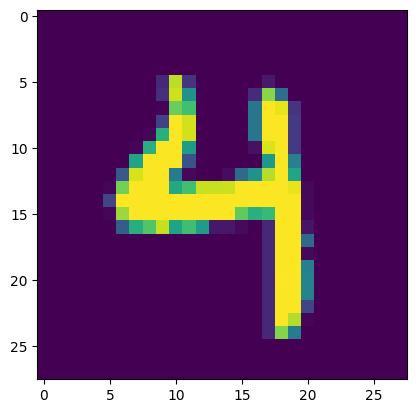

In [81]:
plt.imshow(df.iloc[17561,1:].values.reshape(28,28))

In [82]:
X=df.iloc[:,1:]
y=df.iloc[:,0]

In [83]:
from sklearn.model_selection import train_test_split

In [84]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [85]:
X_train.shape

(33600, 784)

In [86]:
from sklearn.neighbors import KNeighborsClassifier

In [87]:
knn=KNeighborsClassifier()

In [88]:
knn.fit(X_train,y_train)

KNeighborsClassifier()

In [89]:

import time
start=time.time()
y_pred=knn.predict(X_test)
print(time.time()-start)

15.172361850738525


In [90]:
from sklearn.metrics import accuracy_score
accuracy_score(y_test,y_pred)

0.9648809523809524

In [91]:
# Now we will use PCA

In [92]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()

In [93]:
X_train=scaler.fit_transform(X_train)
X_test=scaler.transform(X_test)

In [94]:
# Main PCA
from sklearn.decomposition import PCA
pca=PCA(n_components=None)     # We can take as much column we want

In [95]:
X_train=pca.fit_transform(X_train)
X_test=pca.transform(X_test)

In [96]:
X_train.shape

(33600, 784)

In [97]:
pca=PCA(n_components=200)
X_train_trf=pca.fit_transform(X_train)
X_test_trf=pca.transform(X_test)
X_train_trf.shape

(33600, 200)

In [98]:
knn=KNeighborsClassifier()
knn.fit(X_train_trf,y_train)

KNeighborsClassifier()

In [99]:
y_pred=knn.predict(X_test_trf)

In [100]:
accuracy_score(y_test,y_pred)

0.9507142857142857

In [101]:
for i in range(10,20):
    pca=PCA(n_components=i)
    X_train_trf1=pca.fit_transform(X_train)
    X_test_trf1=pca.transform(X_test)

    knn=KNeighborsClassifier()

    knn.fit(X_train_trf1,y_train)

    y_pred=knn.predict(X_test_trf1)
    
    print(accuracy_score(y_test,y_pred))    

0.9055952380952381
0.9116666666666666
0.9184523809523809
0.9276190476190476
0.9351190476190476
0.9384523809523809
0.9379761904761905
0.9407142857142857
0.94
0.9425


In [102]:
# Visualization of 784 dataset into a 2D coordination system
pca=PCA(n_components=2)
X_train_trf2=pca.fit_transform(X_train)
X_test_trf2=pca.transform(X_test)

In [103]:
import plotly.express as px
y_train_trf2=y_train.astype(str)
fig=px.scatter(x=X_train_trf2[:,0],
               y=X_train_trf2[:,1],
               color=y_train_trf2,
               color_discrete_sequence=px.colors.qualitative.G10             
              )
fig.show()

In [104]:
# 3D visualization
pca=PCA(n_components=3)
X_train_trf3=pca.fit_transform(X_train)
X_test_trf3=pca.transform(X_test)

In [105]:
y_train_trf3=y_train.astype(str)
fig=px.scatter_3d(df,
                  x=X_train_trf3[:,0],
                  y=X_train_trf3[:,1],
                  z=X_train_trf3[:,2],
                  color=y_train_trf3
                 )
fig.update_layout(
    margin=dict(l=20,r=20,t=20,b=20)
)
fig.show()

In [106]:
#Eigen values
pca.explained_variance_

array([40.67111198, 29.17023401, 26.74459621])

In [107]:
#Eigen vectora
pca.components_

array([[ 1.00000000e+00,  2.19776133e-15,  1.37064593e-15, ...,
         2.09022713e-17,  1.51399921e-16, -2.46632295e-17],
       [-2.19776133e-15,  1.00000000e+00, -1.37667655e-14, ...,
        -2.03644069e-16,  3.07893560e-16, -4.91764087e-17],
       [-1.37064593e-15,  1.44328993e-14,  1.00000000e+00, ...,
         1.24603459e-16,  2.75744113e-17, -6.52417048e-17]],
      shape=(3, 784))

In [108]:
pca=PCA(n_components=None)
X_train_trf4=pca.fit_transform(X_train)
X_test_trf4=pca.transform(X_test)

In [111]:
pca.explained_variance_.shape

(784,)

In [113]:
pca.components_.shape
# 784 PCA in 784 dimentional space

(784, 784)

In [115]:
np.cumsum(pca.explained_variance_ratio_)

array([0.05785192, 0.09934462, 0.13738701, 0.16704964, 0.19286525,
       0.21541506, 0.23514574, 0.25289854, 0.26858504, 0.28294568,
       0.29664822, 0.30892077, 0.32038989, 0.33162017, 0.34220546,
       0.35240477, 0.36198153, 0.37140862, 0.38053351, 0.38943521,
       0.39783462, 0.40603525, 0.41388828, 0.42145568, 0.42882829,
       0.43584714, 0.44282633, 0.44953738, 0.45593583, 0.4622392 ,
       0.46839271, 0.4744166 , 0.48025334, 0.48603881, 0.49176214,
       0.49722614, 0.50265822, 0.50793994, 0.51307376, 0.51801392,
       0.52289063, 0.52771041, 0.53239246, 0.53698588, 0.54156249,
       0.54605468, 0.5505015 , 0.55491691, 0.55926803, 0.56358836,
       0.56780645, 0.57198888, 0.57606882, 0.58008887, 0.58407223,
       0.58801822, 0.59188694, 0.59571889, 0.59948441, 0.60322635,
       0.60687487, 0.6104829 , 0.61402176, 0.61750117, 0.62094441,
       0.62432378, 0.62767368, 0.63099377, 0.63426257, 0.63746765,
       0.64065542, 0.64376931, 0.64686564, 0.64992395, 0.65296

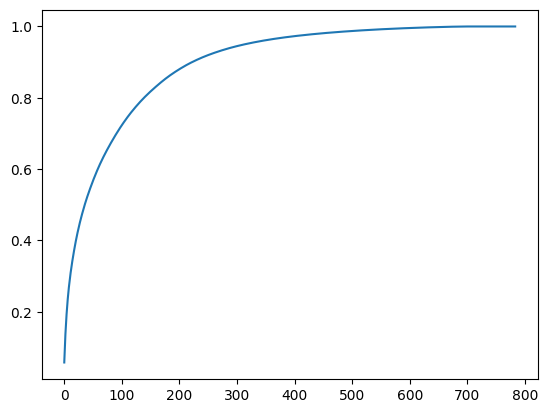

In [116]:
plt.plot(np.cumsum(pca.explained_variance_ratio_))